In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style to resemble ggplot2
sns.set_theme(style="whitegrid")

# Parameters to simulate binary classification dataset with label noise
seed_parameter = 123
n = 10000          # sample size
p = 100            # number of covariates
corr_factor = 0.5  # correlation factor between predictors
flip_factor = 0.15 # label noise factor

# set hyperparameters for MLP training
epochs = 50                 # epochs
batch_sizes = [4]           # mini-batch size
hidden_sizes = [16, 64, 256] # hidden layer dimension
base_step_size = 0.1        # initial value of step size
decay_rate = 0.7            # decreases step size on a fixed schedule

In [6]:
def generate_correlated_data(n_samples=n, n_features=p, rho=corr_factor, flip_f=flip_factor, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Covariance matrix with correlation rho
    Sigma = np.full((n_features, n_features), rho)
    np.fill_diagonal(Sigma, 1.0)

    # Generate predictors (X) from multivariate normal distribution
    mu = np.zeros(n_features)
    X = np.random.multivariate_normal(mean=mu, cov=Sigma, size=n_samples)

    # Define true coefficients for logistic regression
    beta = np.random.uniform(-1, 1, n_features)
    logits = X @ beta

    # Convert logits to probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Generate class labels
    y = np.random.binomial(1, probs)

    # add noise in the labels by flipping a percentage of them
    flip_idx = np.random.choice(n_samples, size=int(flip_f * n_samples), replace=False)
    y[flip_idx] = 1 - y[flip_idx]

    return X, y.reshape(-1, 1)

# Generate dataset
X, y = generate_correlated_data(n_samples=n, n_features=p, rho=corr_factor,
                                flip_f=flip_factor, seed=seed_parameter)

# Set-up size of training, validation and test data set
train_end = int(0.6 * n)
val_end = int(0.8 * n)

# Data split
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(y_train.shape)
print(X_train.shape)

(6000, 1)
(6000, 100)


In [7]:
# Helper functions
def sigmoid(x):
    # np.clip prevents overflow in exp
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def relu(x):
    return np.maximum(0, x)

def bce_loss(y_true, y_pred):
    eps = 1e-8
    n_obs = len(y_true)
    return -np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)) / n_obs

# Xavier initialization function
def xavier_init(in_dim, out_dim):
    limit = np.sqrt(6 / (in_dim + out_dim))
    return np.random.uniform(-limit, limit, size=(in_dim, out_dim))

# He initialization function
def he_init(in_dim, out_dim):
    stddev = np.sqrt(2 / in_dim)
    return np.random.normal(0, stddev, size=(in_dim, out_dim))

In [8]:
# Store results
results = {}

# Initialize variables to track best model
best_model = None
best_val_loss = float('inf')

### THIS PART OF THE CODE CONTAINS THE CORE OF SGD FOR THE MLP
# Training loop

for batch_size in batch_sizes:
    for hidden_size in hidden_sizes:

        # Initialize weights
        W1 = he_init(p, hidden_size)
        b1 = np.zeros((1, hidden_size))
        W2 = xavier_init(hidden_size, 1)
        b2 = np.zeros((1, 1))

        train_loss_history = []
        val_loss_history = []

        n_train = X_train.shape[0]

        for epoch in range(epochs):
            # Learning rate schedule (epoch is 0-indexed in python, so we just use epoch)
            lr = base_step_size * (decay_rate ** epoch)

            # Shuffle training data
            idx = np.random.permutation(n_train)
            X_train_shuffled = X_train[idx]
            y_train_shuffled = y_train[idx]

            for i in range(0, n_train, batch_size):
                batch_end = min(i + batch_size, n_train)
                X_batch = X_train_shuffled[i:batch_end]
                y_batch = y_train_shuffled[i:batch_end]

                current_batch_size = X_batch.shape[0]

                # Forward pass
                # Python broadcasting handles the bias addition automatically
                A = X_batch @ W1 + b1
                H = relu(A)
                Z = H @ W2 + b2
                y_hat = sigmoid(Z)

                # Backward pass
                dZ = y_hat - y_batch
                dW2 = (H.T @ dZ) / current_batch_size
                db2 = np.mean(dZ, axis=0, keepdims=True)

                dH = dZ @ W2.T
                dA = dH * (A > 0)  # ReLU derivative
                dW1 = (X_batch.T @ dA) / current_batch_size
                db1 = np.mean(dA, axis=0, keepdims=True)

                # Update weights
                W1 -= lr * dW1
                b1 -= lr * db1
                W2 -= lr * dW2
                b2 -= lr * db2

            # Compute and track loss
            A_train = relu(X_train @ W1 + b1)
            y_train_pred = sigmoid(A_train @ W2 + b2)
            train_loss = bce_loss(y_train, y_train_pred)

            A_val = relu(X_val @ W1 + b1)
            y_val_pred = sigmoid(A_val @ W2 + b2)
            val_loss = bce_loss(y_val, y_val_pred)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)

        # Save training history
        key = f"Batch_{batch_size}_Hidden_{hidden_size}"
        results[key] = {'train': train_loss_history, 'val': val_loss_history}

        # Update best model
        if min(val_loss_history) < best_val_loss:
            best_val_loss = min(val_loss_history)
            best_model = {'W1': W1.copy(), 'b1': b1.copy(),
                          'W2': W2.copy(), 'b2': b2.copy(),
                          'val_loss': best_val_loss}

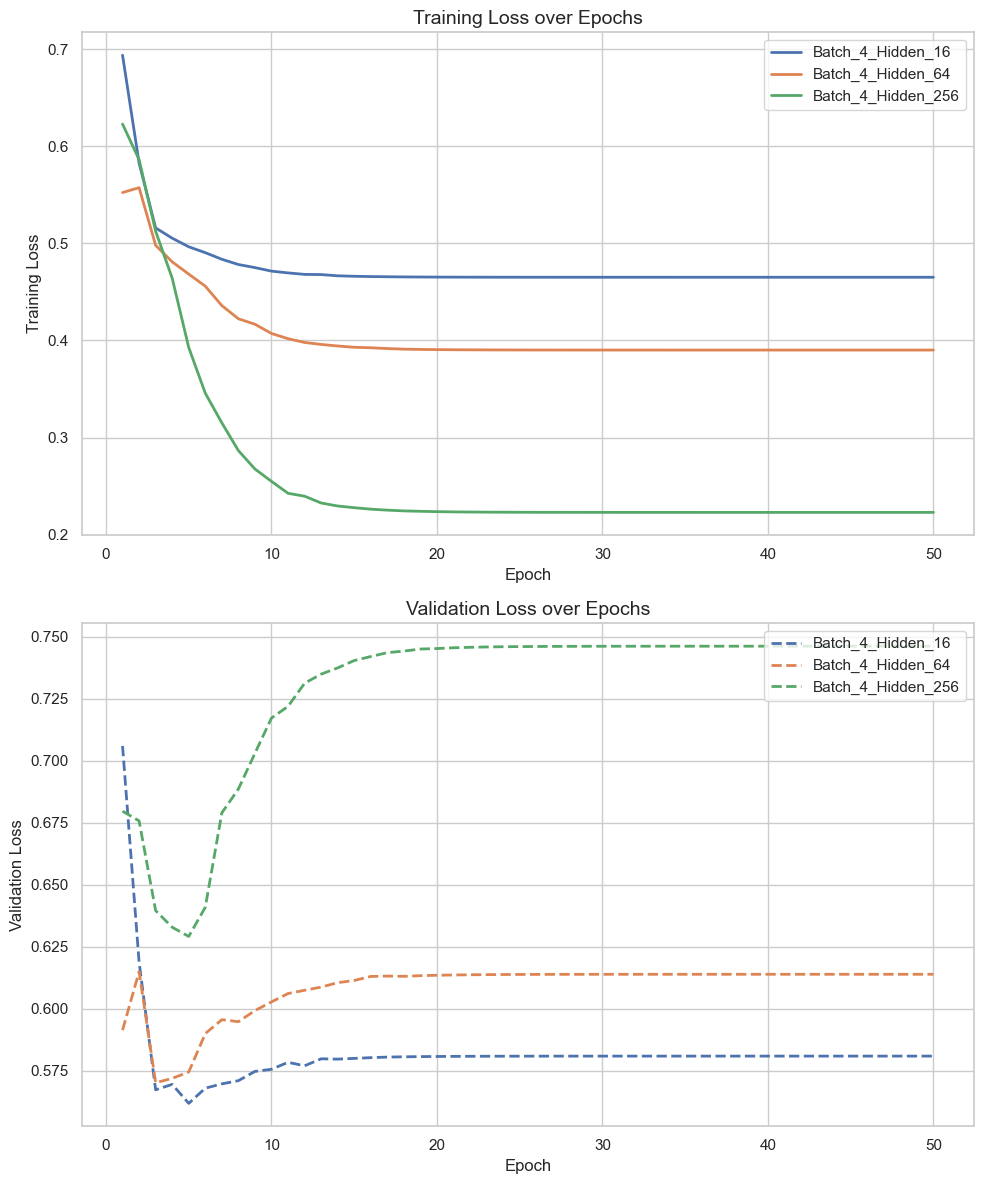

In [9]:
# Prepare data for plotting
plot_data = []
for key, values in results.items():
    for epoch in range(epochs):
        plot_data.append({
            'Epoch': epoch + 1,
            'Loss': values['train'][epoch],
            'LossType': 'Training',
            'Model': key
        })
        plot_data.append({
            'Epoch': epoch + 1,
            'Loss': values['val'][epoch],
            'LossType': 'Validation',
            'Model': key
        })

loss_df = pd.DataFrame(plot_data)

# Create the plots
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# === Training Loss Plot ===
train_df = loss_df[loss_df['LossType'] == 'Training']
sns.lineplot(data=train_df, x='Epoch', y='Loss', hue='Model',
             linewidth=2, ax=axes[0])
axes[0].set_title("Training Loss over Epochs", fontsize=14)
axes[0].set_ylabel("Training Loss")
axes[0].legend(loc='upper right')

# === Validation Loss Plot ===
val_df = loss_df[loss_df['LossType'] == 'Validation']
sns.lineplot(data=val_df, x='Epoch', y='Loss', hue='Model',
             linewidth=2, linestyle='--', ax=axes[1])
axes[1].set_title("Validation Loss over Epochs", fontsize=14)
axes[1].set_ylabel("Validation Loss")
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()